**IMPORT LIBRARY DAN LOAD DATA**

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
import numpy as np
import pandas as pd
import os
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from google.colab import files
uploaded = files.upload()

Saving gender_submission.csv to gender_submission.csv
Saving test.csv to test.csv
Saving train.csv to train.csv


**EKSPLORASI DATA AWAL (EDA)**

In [ ]:
# === INFORMASI STRUKTUR DAN TIPE DATA ===

train_data = pd.read_csv("train.csv")
train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
# === INFORMASI STRUKTUR DAN TIPE DATA ===

test_data = pd.read_csv("test.csv")
test_data.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [ ]:
# === INFORMASI STRUKTUR DAN TIPE DATA ===

gender_data = pd.read_csv("gender_submission.csv")
gender_data.head()

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


In [ ]:
# === STATISTIK DESKTIPTIF ===

print("=== Informasi Dataset ===")
print("\nTrain Data:")
print(train_data.info())
print("\nTest Data:")
print(test_data.info())
print("\nGender Submission:")
print(gender_data.info())

print("\n=== Statistik Deskriptif ===")
print("\nTrain Data Description:")
print(train_data.describe())

=== Informasi Dataset ===

Train Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None

Test Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  

In [ ]:
# === DISTRIBUSI DATA ===

print("\n=== Distribusi Target ===")
if 'Survived' in train_data.columns:
    print("\nDistribusi Kelangsungan Hidup (Training):")
    print(train_data['Survived'].value_counts(normalize=True))


=== Distribusi Target ===

Distribusi Kelangsungan Hidup (Training):
Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64


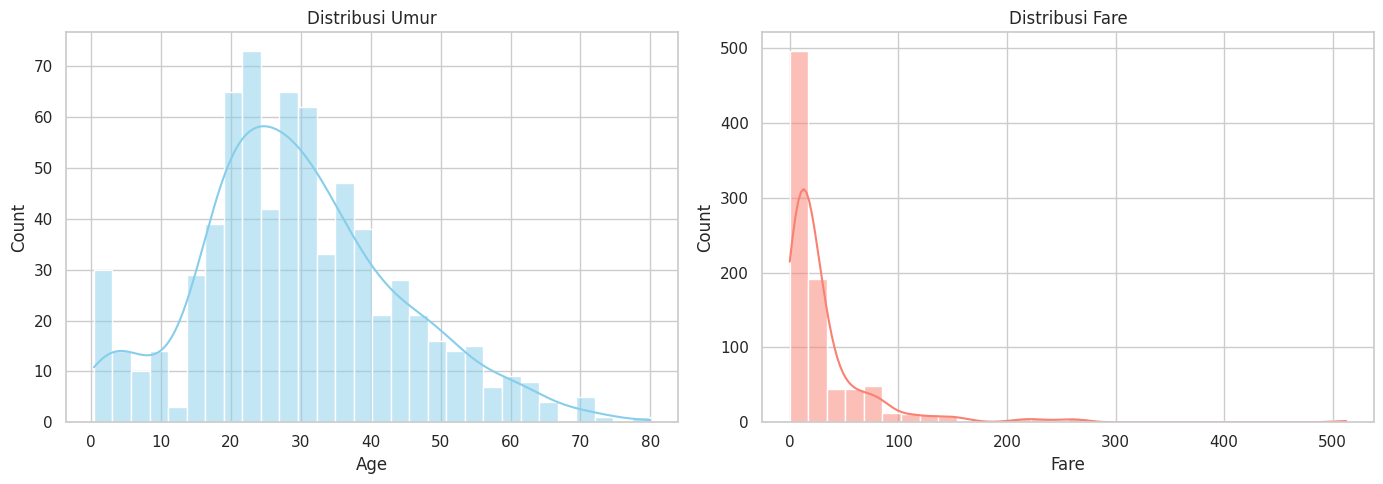

In [ ]:
# === VISUALISASI DISTRIBUSI DATA ===
sns.set(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(train_data['Age'].dropna(), kde=True, ax=axes[0], bins=30, color='skyblue')
axes[0].set_title("Distribusi Umur")
sns.histplot(train_data['Fare'], kde=True, ax=axes[1], bins=30, color='salmon')
axes[1].set_title("Distribusi Fare")
plt.tight_layout()
plt.show()


In [ ]:
# === MISSING VALUES ===

print("\n=== Cek Missing Values ===")
print("\nTrain Data Missing Values:")
print(train_data.isnull().sum())
print("\nTest Data Missing Values:")
print(test_data.isnull().sum())


=== Cek Missing Values ===

Train Data Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Test Data Missing Values:
PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64


FEATURE ENGINEERING

In [ ]:
def preprocess_titanic_data(df, is_train=True):

    # Buat salinan dataframe
    df_processed = df.copy()

    # 1. Fitur Baru: Ukuran Keluarga
    df_processed['FamilySize'] = df_processed['SibSp'] + df_processed['Parch'] + 1
    df_processed['IsAlone'] = (df_processed['FamilySize'] == 1).astype(int)


    # 2. Handle missing values
    df_processed['Age'].fillna(df_processed['Age'].median(), inplace=True)
    df_processed['Fare'].fillna(df_processed['Fare'].median(), inplace=True)
    df_processed['Embarked'].fillna(df_processed['Embarked'].mode()[0], inplace=True)

    # 3. Encode categorical features
    le = LabelEncoder()
    df_processed['Sex'] = le.fit_transform(df_processed['Sex'])
    df_processed['Embarked'] = le.fit_transform(df_processed['Embarked'].astype(str))

    # 4. Extract Title from Name
    df_processed['Title'] = df_processed['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
    df_processed['Title'] = df_processed['Title'].replace(['Lady', 'Countess','Capt', 'Col', 'Don',
                                                         'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
    df_processed['Title'] = df_processed['Title'].replace(['Mlle', 'Ms'], 'Miss')
    df_processed['Title'] = df_processed['Title'].replace('Mme', 'Mrs')
    df_processed['Title'] = le.fit_transform(df_processed['Title'])

    # 5. Binning (kelompok usia, tarif, dan keluarga)
    df_processed['AgeBin'] = pd.cut(df_processed['Age'], bins=[0, 12, 20, 40, 60, 80],
                                    labels=['Anak', 'Remaja', 'Dewasa Muda', 'Dewasa', 'Lansia'])
    df_processed['FareBin'] = pd.qcut(df_processed['Fare'], 4,
                                      labels=['Murah', 'Sedang', 'Mahal', 'Sangat Mahal'])
    df_processed['FamilyGroup'] = pd.cut(df_processed['FamilySize'], bins=[0,1,3,5,11],
                                         labels=['Sendiri','Kecil','Sedang','Besar'])
    df_processed['PclassGroup'] = df_processed['Pclass'].map({1:'Kelas 1', 2:'Kelas 2', 3:'Kelas 3'})

    # 6. Drop columns yang tidak diperlukan
    columns_to_drop = ['Name', 'Ticket', 'Cabin']
    df_processed.drop(columns_to_drop, axis=1, inplace=True, errors='ignore')

    # 7. Pisahkan features dan target untuk data training
    if is_train and 'Survived' in df_processed.columns:
        y = df_processed['Survived']
        X = df_processed.drop('Survived', axis=1)
        return X, y

    return df_processed

# Proses data training
X_train, y_train = preprocess_titanic_data(train_data, is_train=True)

# Proses data test
X_test = preprocess_titanic_data(test_data, is_train=False)

# Gabungkan gender_submission dengan test data untuk evaluasi
if not gender_data.empty and not test_data.empty:
    test_results = pd.merge(
        test_data[['PassengerId']],
        gender_data,
        on='PassengerId',
        how='left'
    )
    y_test = test_results['Survived'] if 'Survived' in test_results.columns else None
else:
    y_test = None

print("\nData setelah preprocessing:")
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
if y_test is not None:
    print("y_test shape:", y_test.shape)


Data setelah preprocessing:
X_train shape: (891, 15)
y_train shape: (891,)
X_test shape: (418, 15)
y_test shape: (418,)


<ipython-input-229-51d6ad07febe>:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_processed['Age'].fillna(df_processed['Age'].median(), inplace=True)
<ipython-input-229-51d6ad07febe>:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value

In [ ]:
from google.colab import drive

def save_processed_data(X_train, y_train, X_test, y_test=None):
    """Menyimpan data yang sudah diproses ke Google Drive"""
    # Mount Google Drive
    drive.mount('/content/drive')

    # Buat direktori jika belum ada
    save_path = '/content/drive/MyDrive/titanic_processed'
    !mkdir -p "{save_path}"

    # Simpan data
    X_train.to_csv(f'{save_path}/X_train.csv', index=False)
    y_train.to_csv(f'{save_path}/y_train.csv', index=False)
    X_test.to_csv(f'{save_path}/X_test.csv', index=False)

    if y_test is not None:
        y_test.to_csv(f'{save_path}/y_test.csv', index=False)

    print(f"Data berhasil disimpan di Google Drive: {save_path}")

# Simpan data yang sudah diproses
save_processed_data(X_train, y_train, X_test, y_test)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Data berhasil disimpan di Google Drive: /content/drive/MyDrive/titanic_processed


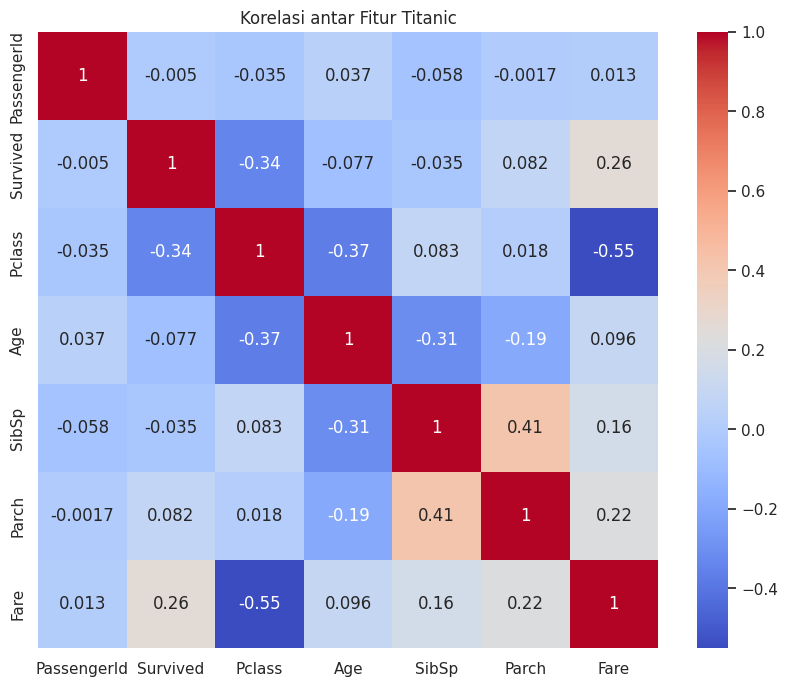

In [ ]:
# === HEATMAP KORELASI ANTAR FITUR ===
plt.figure(figsize=(10,8))

# Select only numeric features for correlation calculation
numeric_features = train_data.select_dtypes(include=np.number)

# Korelasi Antar Fitur
sns.heatmap(numeric_features.corr(), annot=True, cmap='coolwarm')
plt.title("Korelasi antar Fitur Titanic")
plt.show()

In [ ]:
# === ANALISIS HASIL SEGMENTASI ===

# Terapkan Preprocessing (Binning) pada train_data
X_train, y_train = preprocess_titanic_data(train_data, is_train=True)
train_data_processed = X_train.copy()
train_data_processed['Survived'] = y_train

# Buat DataFrame untuk menampung hasil segmentasi survival rate
segmentasi_results = {}

# Daftar fitur hasil binning
binning_features = {
    'Pclass': 'Kelas Penumpang',
    'Sex': 'Jenis Kelamin',
    'Embarked': 'Pelabuhan Keberangkatan',
    'Title': 'Gelar',
    'AgeBin': 'Umur',
    'FareBin': 'Harga Tiket',
    'FamilyGroup': 'Ukuran Keluarga',
}

# Hitung survival rate per kategori pada tiap fitur binning
for feature, label in binning_features.items():
    grouped = train_data_processed.groupby(feature)['Survived'].agg(['count', 'sum', 'mean']).rename(
        columns={
            'count': 'Jumlah Penumpang',
            'sum': 'Jumlah Selamat',
            'mean': 'Persentase Selamat'
        }
    )
    grouped.index.name = label
    grouped['Persentase Selamat'] = grouped['Persentase Selamat'] * 100
    segmentasi_results[label] = grouped

# Tampilkan hasil segmentasi survival rate
for label, df in segmentasi_results.items():
    print(f"\n=== Segmentasi Survival Rate berdasarkan {label} ===")
    display(df.style.format({
        'Persentase Selamat': '{:.2f}%',
        'Jumlah Penumpang': '{:,.0f}',
        'Jumlah Selamat': '{:,.0f}'
    }))



=== Segmentasi Survival Rate berdasarkan Kelas Penumpang ===


<ipython-input-221-51d6ad07febe>:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_processed['Age'].fillna(df_processed['Age'].median(), inplace=True)
<ipython-input-221-51d6ad07febe>:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value

,Jumlah Penumpang,Jumlah Selamat,Persentase Selamat
Kelas Penumpang,,,
1,216,136,62.96%
2,184,87,47.28%
3,491,119,24.24%



=== Segmentasi Survival Rate berdasarkan Jenis Kelamin ===


,Jumlah Penumpang,Jumlah Selamat,Persentase Selamat
Jenis Kelamin,,,
0,314,233,74.20%
1,577,109,18.89%


...

,Jumlah Penumpang,Jumlah Selamat,Persentase Selamat
Umur,,,
Anak,69,40,57.97%
Remaja,110,42,38.18%
Dewasa Muda,562,205,36.48%
Dewasa,128,50,39.06%
Lansia,22,5,22.73%



=== Segmentasi Survival Rate berdasarkan Harga Tiket ===


,Jumlah Penumpang,Jumlah Selamat,Persentase Selamat
Harga Tiket,,,
Murah,223,44,19.73%
Sedang,224,68,30.36%
Mahal,222,101,45.50%
Sangat Mahal,222,129,58.11%



=== Segmentasi Survival Rate berdasarkan Ukuran Keluarga ===


,Jumlah Penumpang,Jumlah Selamat,Persentase Selamat
Ukuran Keluarga,,,
Sendiri,537,163,30.35%
Kecil,263,148,56.27%
Sedang,44,24,54.55%
Besar,47,7,14.89%


<ipython-input-230-5635dc10c6e5>:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  survival_rate = df.groupby(feature)['Survived'].mean()
<ipython-input-230-5635dc10c6e5>:28: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  percentage = survival_rate.get(idx, 0)
<ipython-input-230-5635dc10c6e5>:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  survival_rate = df.groupby(feature)['Survived'].mean()
<ipython-input-230-5635dc10c6e

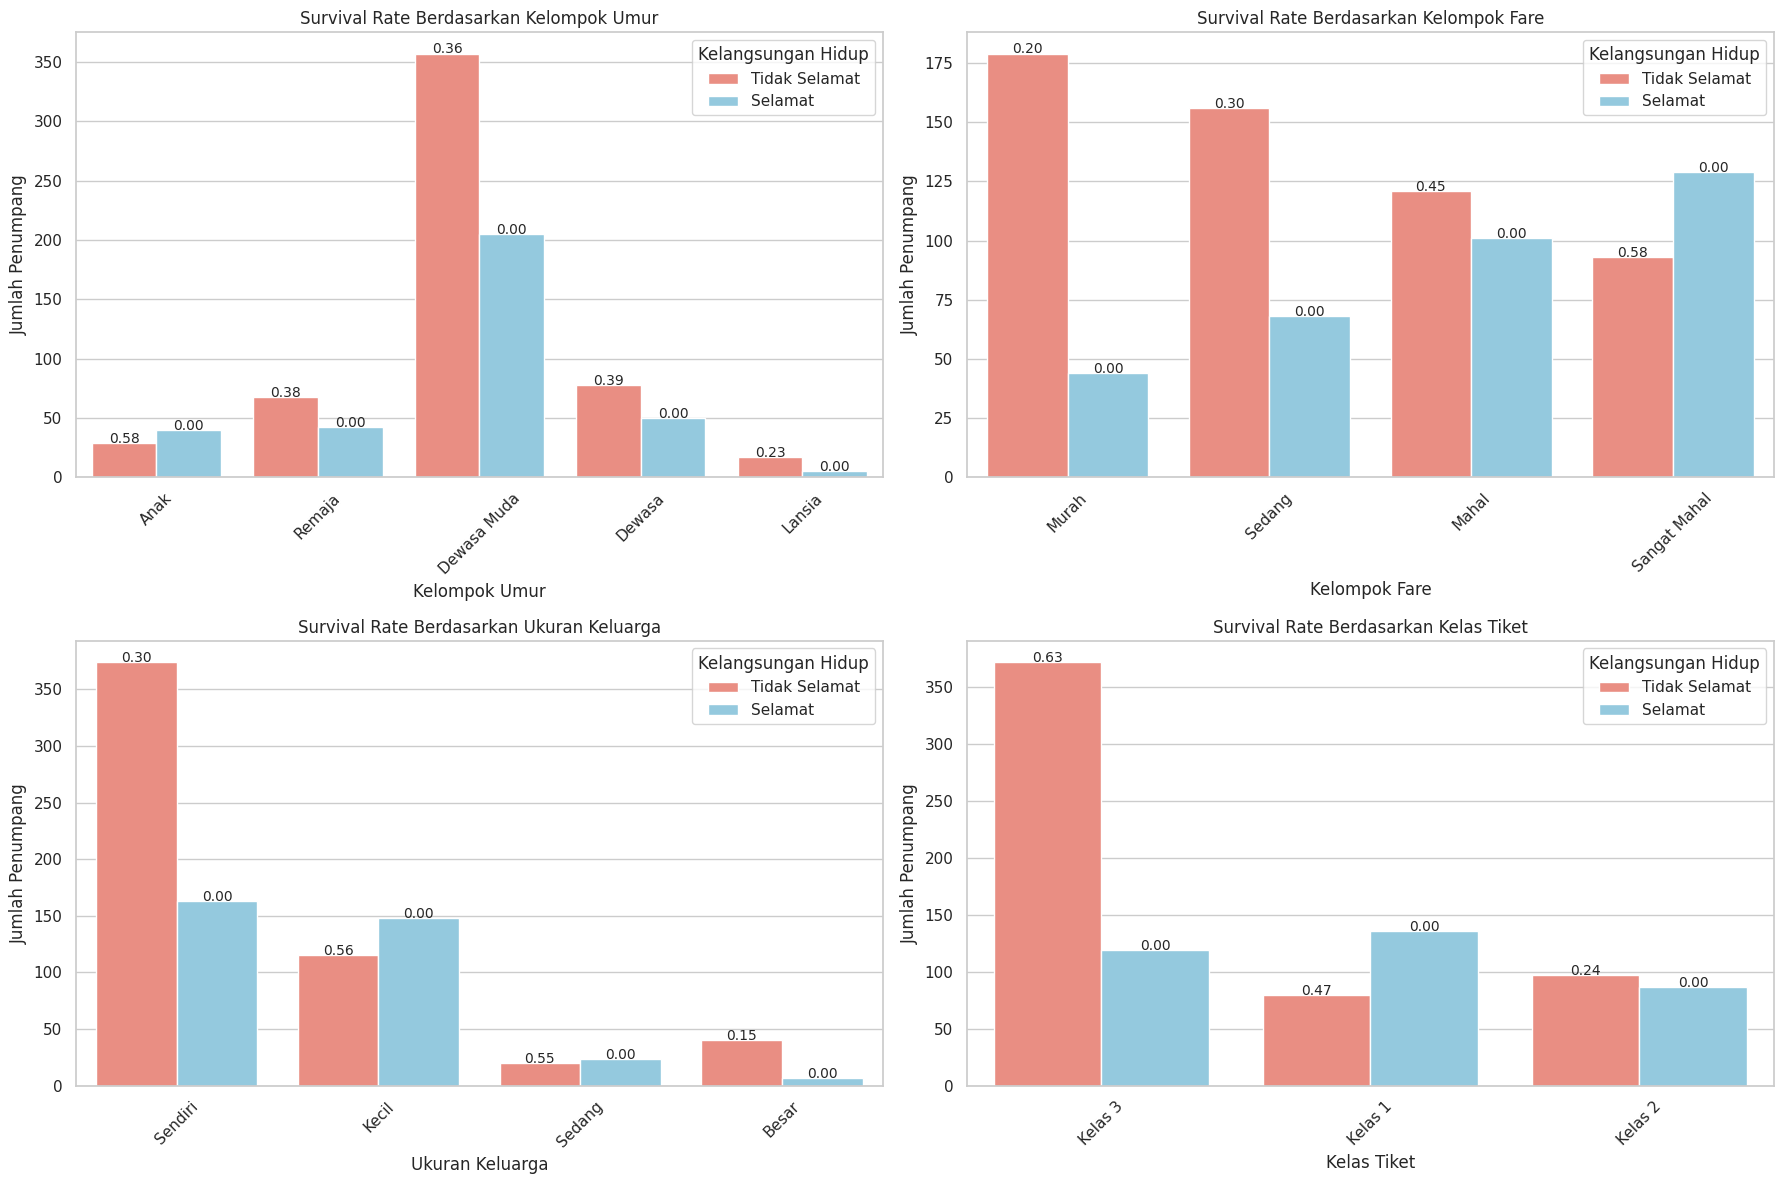

In [ ]:
# === VISUALISASI SURVIVAL RATE  ===

def plot_each_binning_survival(X, y):
    df = X.copy()
    df['Survived'] = y

    binning_features = [
        ('AgeBin', 'Kelompok Umur'),
        ('FareBin', 'Kelompok Fare'),
        ('FamilyGroup', 'Ukuran Keluarga'),
        ('PclassGroup', 'Kelas Tiket')
    ]

    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    colors = ['salmon', 'skyblue']
    for i, (feature, label) in enumerate(binning_features):
        row, col = i // 2, i % 2
        ax = axes[row, col]

        # Buat countplot
        sns.countplot(x=feature, hue='Survived', data=df, palette=colors, ax=ax)

        # Menambahkan angka persentase di atas tiap bar
        survival_rate = df.groupby(feature)['Survived'].mean()
        for idx, p in enumerate(ax.patches):
            height = p.get_height()
            if height > 0:
                percentage = survival_rate.get(idx, 0)
                ax.text(p.get_x() + p.get_width() / 2., height + 0.03, f"{percentage:.2f}", ha='center', fontsize=10)

        ax.set_title(f"Survival Rate Berdasarkan {label}")
        ax.set_xlabel(label)
        ax.set_ylabel("Jumlah Penumpang")
        ax.tick_params(axis='x', rotation=45)
        ax.legend(title='Kelangsungan Hidup', labels=['Tidak Selamat', 'Selamat'])


    plt.tight_layout()
    plt.show()

plot_each_binning_survival(X_train, y_train)

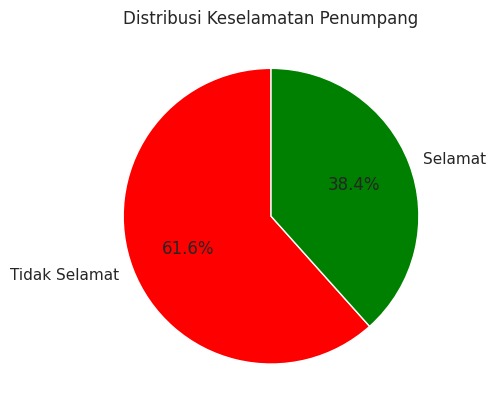

In [ ]:
# === PIE CHART SURVIVAL ===
train_data['Survived'].value_counts().plot.pie(
    autopct='%1.1f%%', startangle=90,
    labels=['Tidak Selamat', 'Selamat'], colors=['red', 'green'])
plt.title("Distribusi Keselamatan Penumpang")
plt.ylabel("")
plt.show()


<ipython-input-229-51d6ad07febe>:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_processed['Age'].fillna(df_processed['Age'].median(), inplace=True)
<ipython-input-229-51d6ad07febe>:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value

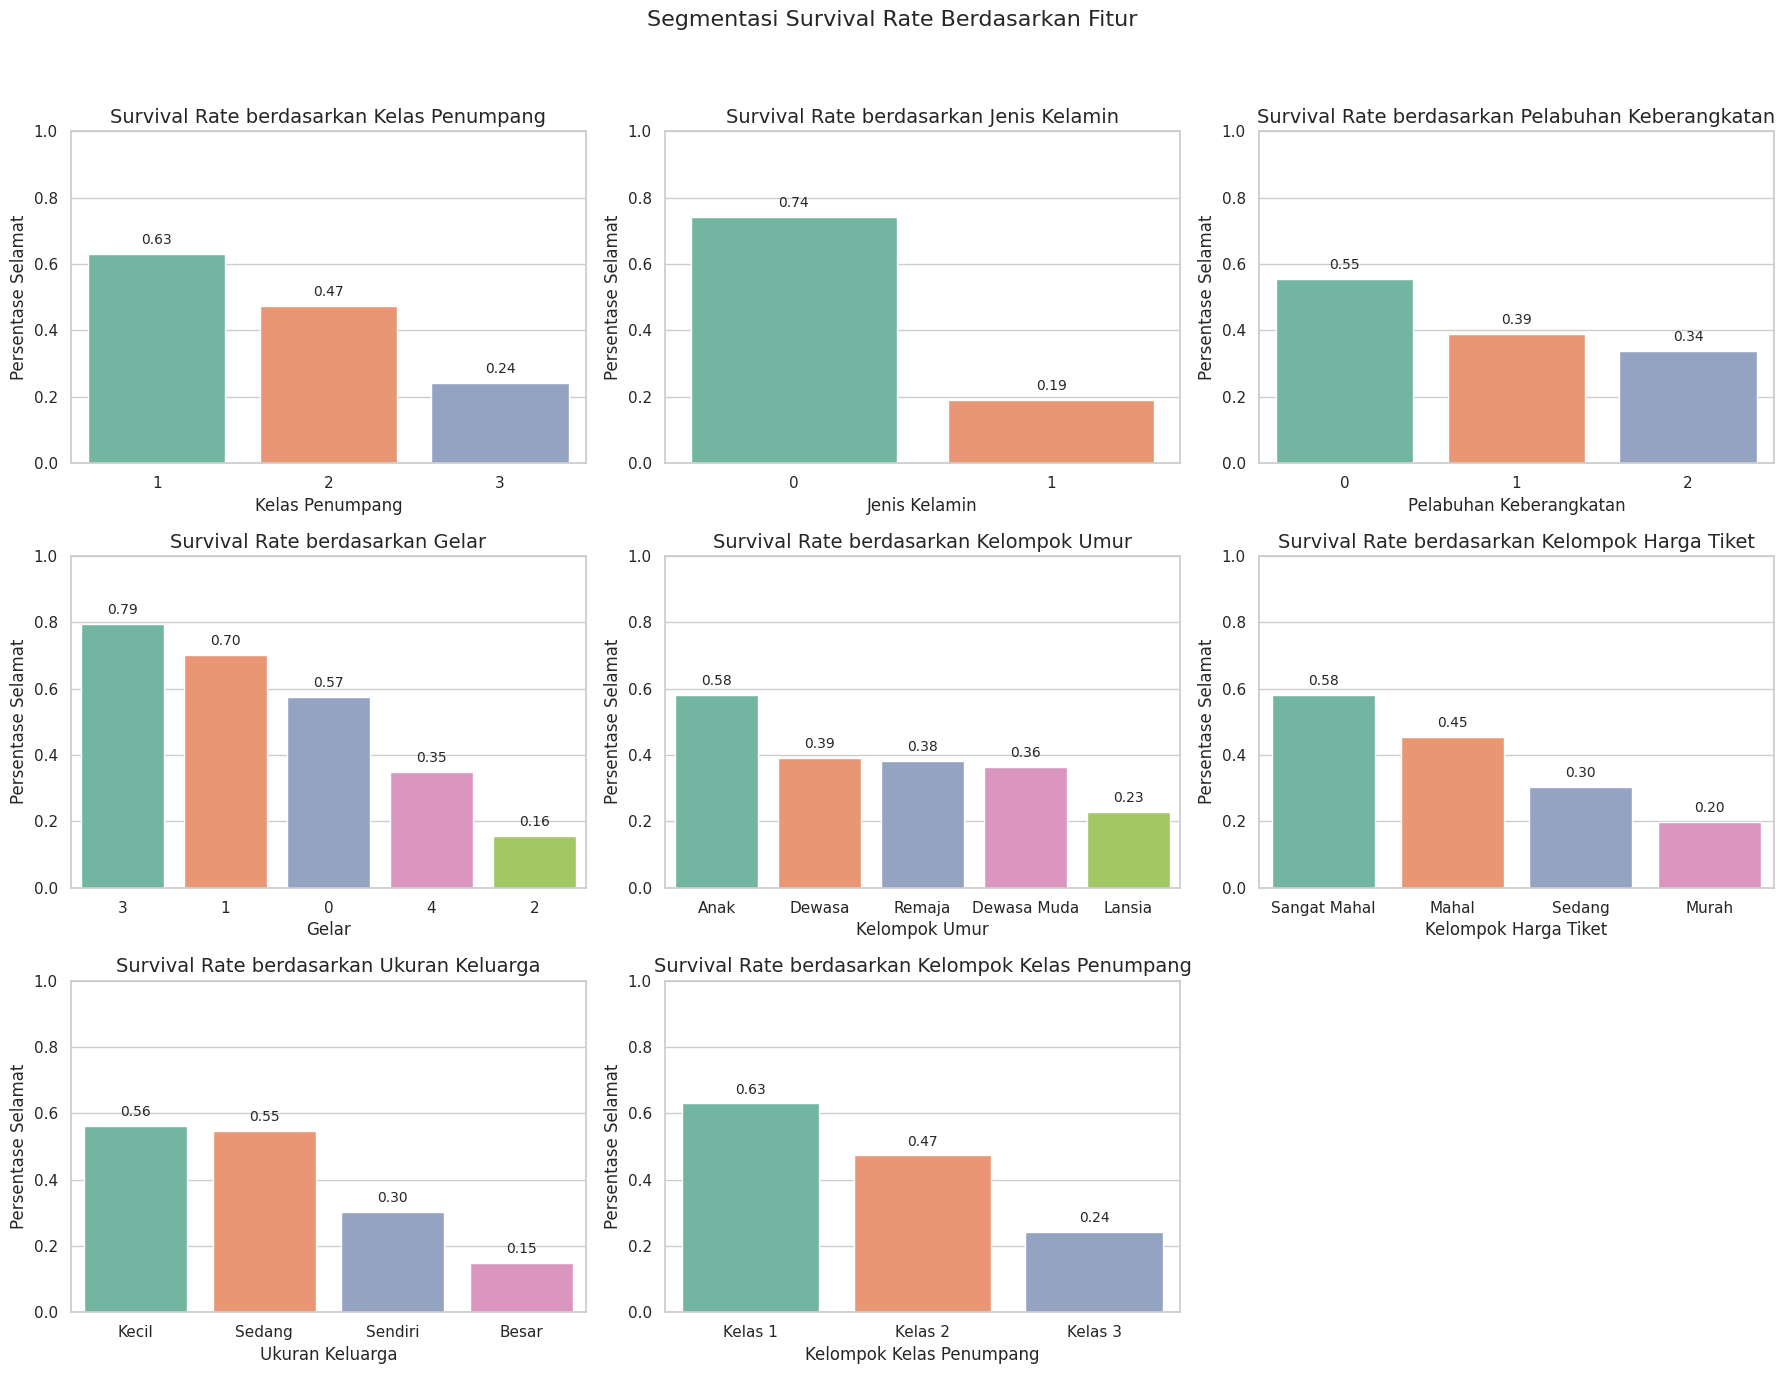

In [ ]:
# === ANALISIS SURVIVAL RATE ===

# Terapkan Preprocessing (Binning) pada train_data
X_train, y_train = preprocess_titanic_data(train_data, is_train=True)
df = X_train.copy() # Use the preprocessed data instead of original train_data
df['Survived'] = y_train

# Definisikan fitur-fitur yang akan divisualisasikan
features = {
    'Pclass': 'Kelas Penumpang',
    'Sex': 'Jenis Kelamin',
    'Embarked': 'Pelabuhan Keberangkatan',
    'Title': 'Gelar',
    'AgeBin': 'Kelompok Umur',
    'FareBin': 'Kelompok Harga Tiket',
    'FamilyGroup': 'Ukuran Keluarga',
    'PclassGroup': 'Kelompok Kelas Penumpang'
}

palette = sns.color_palette("Set2")
plt.figure(figsize=(18, 14))

# Iterasi untuk setiap fitur dan buat barplot
for i, (feature, label) in enumerate(features.items(), 1):
    plt.subplot(3, 3, i)  # Menggunakan 3x3 grid untuk memplot
    survival_rate = df.groupby(feature)['Survived'].mean().sort_values(ascending=False)

    # Barplot dengan kategori pada x dan survival rate pada y
    sns.barplot(
        x=survival_rate.index.astype(str),
        y=survival_rate.values,
        palette=palette
    )

    # Label dan judul
    plt.ylim(0, 1)
    plt.title(f'Survival Rate berdasarkan {label}', fontsize=14)
    plt.xlabel(label)
    plt.ylabel('Persentase Selamat')

    # Menambahkan angka persentase di atas tiap bar
    for idx, value in enumerate(survival_rate.values):
        plt.text(idx, value + 0.03, f"{value:.2f}", ha='center', fontsize=10)

# Menambahkan judul keseluruhan
plt.suptitle("Segmentasi Survival Rate Berdasarkan Fitur", fontsize=16)

# Penyesuaian jarak antar subplot untuk menghindari tumpang tindih
plt.subplots_adjust(hspace=0.3, wspace=0.3)  # Menambah jarak antar subplot

plt.tight_layout(rect=[0, 0, 1, 0.95])  # Menyesuaikan layout agar lebih rapih
plt.show()

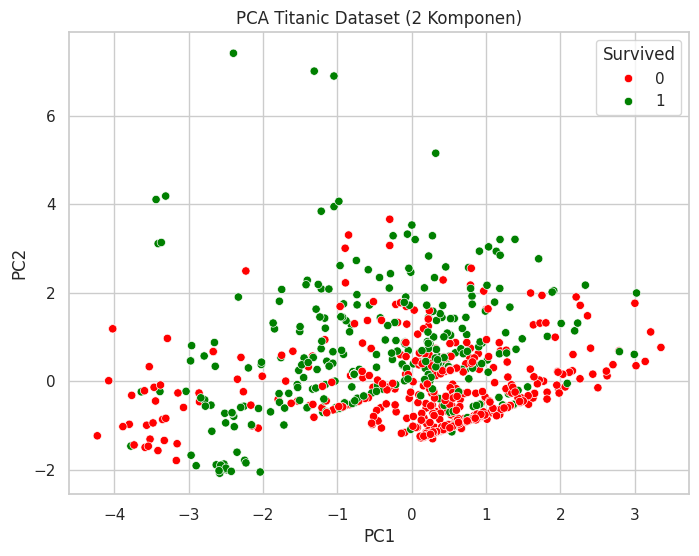

In [ ]:
# === PCA (REDUKSI 2 DIMENSI) ===
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

features = ['Age', 'Fare', 'FamilySize', 'Sex', 'Embarked', 'Title']
x = X_train[features]
x_scaled = StandardScaler().fit_transform(x)

pca = PCA(n_components=2)
components = pca.fit_transform(x_scaled)

df_pca = pd.DataFrame(data=components, columns=['PC1', 'PC2'])
df_pca['Survived'] = y_train

# Visualisasi
plt.figure(figsize=(8,6))
sns.scatterplot(x="PC1", y="PC2", hue="Survived", data=df_pca, palette=["red", "green"])
plt.title("PCA Titanic Dataset (2 Komponen)")
plt.show()


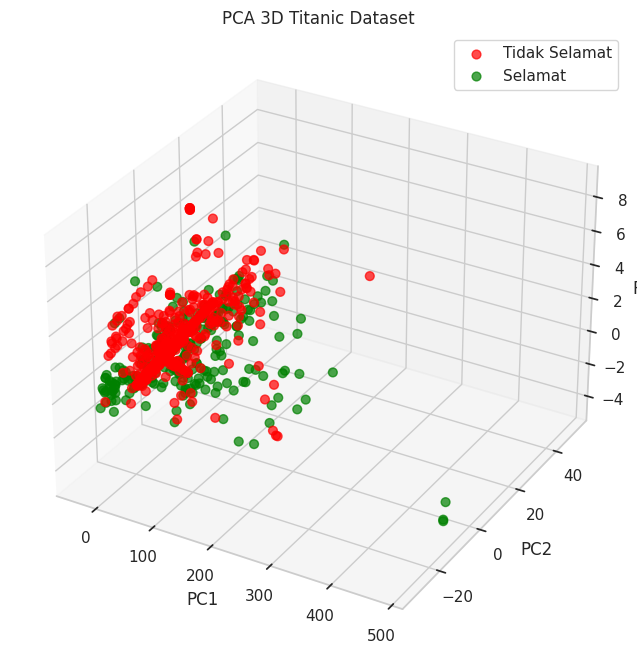

In [ ]:
# === PCA (REDUKSI 3 DIMENSI) ===
from mpl_toolkits.mplot3d import Axes3D

# PCA dengan 3 komponen
pca_3d = PCA(n_components=3)
components_3d = pca_3d.fit_transform(x)

df_pca_3d = pd.DataFrame(data=components_3d, columns=['PC1', 'PC2', 'PC3'])
df_pca_3d = pd.concat([df_pca_3d, train_data['Survived']], axis=1)

# Visualisasi 3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

colors = ['red', 'green']
labels = ['Tidak Selamat', 'Selamat']

for label in [0, 1]:
    subset = df_pca_3d[df_pca_3d['Survived'] == label]
    ax.scatter(
        subset['PC1'], subset['PC2'], subset['PC3'],
        label=labels[label],
        c=colors[label], s=40, alpha=0.7
    )

ax.set_title("PCA 3D Titanic Dataset")
ax.set_xlabel("PC1", fontsize=12)
ax.set_ylabel("PC2", fontsize=12)
ax.set_zlabel("PC3", fontsize=12)
ax.legend()
plt.show()
